In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score


In [7]:
np.random.seed(42)
N = 800
pclass = np.random.choice([1, 2, 3], size=N, p=[0.2, 0.3, 0.5])
sex = np.random.choice(['male', 'female'], size=N, p=[0.62, 0.38])
age = np.clip(np.random.normal(loc=30, scale=14, size=N), 0.4, 80)

In [8]:
fare_base = {1: (60, 25), 2: (25, 10), 3: (10, 6)}
fare = np.array([
    np.clip(np.random.normal(fare_base[c][0], fare_base[c][1]), 1, 200)
    for c in pclass
])

In [ ]:
intercept = -1.0
beta_pclass = {1: 0.9, 2: 0.3, 3: -0.6}
beta_female = 1.0
beta_child = 0.8

logit = (
    intercept
    + np.array([beta_pclass[c] for c in pclass])
    + (sex == 'female') * beta_female
    + (age < 14) * beta_child
)

prob = 1 / (1 + np.exp(-logit))
survived = (np.random.rand(N) < prob).astype(int)

df = pd.DataFrame({
    'Survived': survived,
    'Pclass': pclass,
    'Sex': sex,
    'Age': np.round(age, 1),
    'Fare': np.round(fare, 2),
})

# Add missingness to Age
mask_age_missing = np.random.rand(N) < 0.12
df.loc[mask_age_missing, 'Age'] = np.nan

df.head()

In [ ]:
df.info()

# %%
df.describe(include='all')

# %%
# Handle missing ages using group medians
group_medians = df.groupby(['Pclass', 'Sex'])['Age'].median()

def impute_age(row):
    if pd.isna(row['Age']):
        return group_medians.loc[(row['Pclass'], row['Sex'])]
    return row['Age']

df['Age_imputed'] = df.apply(impute_age, axis=1)
df['Age_was_missing'] = df['Age'].isna().astype(int)

df[['Age', 'Age_imputed', 'Age_was_missing']].head(10)

# %%
# Survival by Sex
survival_by_sex = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)

plt.figure()
survival_by_sex.plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.ylabel('Mean Survival (0-1)')
plt.xlabel('Sex')
plt.tight_layout()
plt.show()

print(survival_by_sex)

# %%
# Survival by Passenger Class
survival_by_class = df.groupby('Pclass')['Survived'].mean()

plt.figure()
survival_by_class.plot(kind='bar')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Mean Survival (0-1)')
plt.xlabel('Pclass')
plt.tight_layout()
plt.show()

print(survival_by_class)


C:\Users\umusa\AppData\Local\Temp\ipykernel_21216\4263311370.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_ageband = df.groupby(ageband)['Survived'].mean()


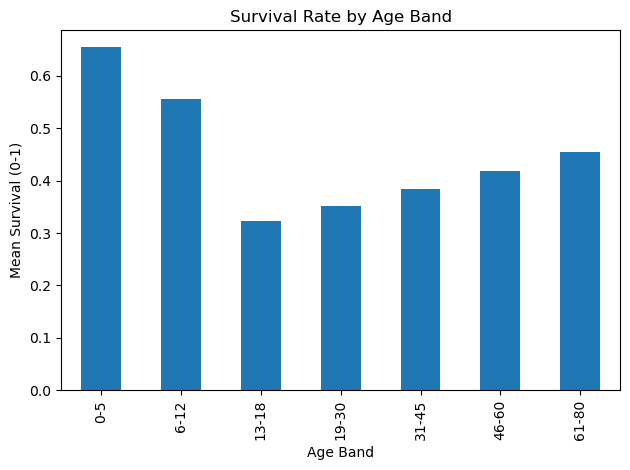

Age_imputed
0-5      0.653846
6-12     0.555556
13-18    0.322581
19-30    0.350943
31-45    0.384106
46-60    0.418367
61-80    0.454545
Name: Survived, dtype: float64


NameError: name 'ColumnTransformer' is not defined

In [11]:
bins = [0, 5, 12, 18, 30, 45, 60, 80]
labels = ['0-5', '6-12', '13-18', '19-30', '31-45', '46-60', '61-80']
ageband = pd.cut(df['Age_imputed'], bins=bins, labels=labels, include_lowest=True)

survival_by_ageband = df.groupby(ageband)['Survived'].mean()

plt.figure()
survival_by_ageband.plot(kind='bar')
plt.title('Survival Rate by Age Band')
plt.ylabel('Mean Survival (0-1)')
plt.xlabel('Age Band')
plt.tight_layout()
plt.show()

print(survival_by_ageband)

# %%
# Logistic Regression Model
X = df[['Pclass', 'Sex', 'Age_imputed', 'Fare']].copy()
y = df['Survived']

numeric_features = ['Pclass', 'Age_imputed', 'Fare']
categorical_features = ['Sex']

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='if_binary'), categorical_features)
    ]
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

clf.fit(X, y)
proba = clf.predict_proba(X)[:, 1]
auc = roc_auc_score(y, proba)

print("Model ROC-AUC:", auc)
